<a href="https://colab.research.google.com/github/anushkach0401/mypy_prog/blob/main/Capstone_prj_brics_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This capstone project consists of 2 parts(A and B) to include maximum part of data analytics and programming.Part A of project revolves around data analysis of GAIA mission; part B revolves around fits data from UIT telescope of NASA.

##Project Part A:  Data Analysis using GAIA data

**Aim:** This project analyses a subset of stellar data from GAIA DR3 mission. This analysis includes data cleaning,data description, calculation of other related parameters, distribution of different parameters with respect to number of stars and distribution of right ascension and declination with repect to colours.

**Data used:** 1000 entries from GAIA DR3 dataset.  https://raw.githubusercontent.com/anushkach0401/brics_astro/main/GAIA_brics.csv

**Meaning of Columns used in data analysis:-**


*   **source_id:** Identifier of each star
*   **ra:** Right ascension


*   **dec:** Declination


*   **parallax:** Stellar parallax


*   **pmra and pmdec:** Proper motion in right ascension and declination respectively


*   **phot_g_mean_mag:** Mean magnitude of G-band
*   **bp_rp:** Colour index


*  **parallax_over_error:** Parallax to its error ratio; measurement quality
*   **phot_bp_mean_mag:** Mean magnitude of bp(Blue Photometer) band


*   **phot_rp_mean_mag:** Mean magnitude of rp(Red Photometer) band

*   **distance_pc:** Distance in parsec
*   **distance_ly:** Distance in light year
* **mg:** Absolute G band magnitude











In [ ]:
#installing required packages
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install astropy

In [ ]:
#including required packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u

In [ ]:
#reading data set
fl=pd.read_csv("https://raw.githubusercontent.com/anushkach0401/brics_astro/main/GAIA_brics.csv")

In [ ]:
#initial data description
print(fl.head())
print("INFO:--")
print(fl.info())
print("DESCRIBE:--")
print(fl.describe())

            source_id         ra        dec  parallax      pmra     pmdec  \
0  137338829195586432  45.118976  35.334231 -1.469404 -0.309280 -0.125769   
1  137339207152695424  45.030681  35.325036  0.984936 -2.118385 -0.981535   
2  137339275872182528  45.016162  35.334053  0.899287 -4.033312  0.064073   
3  137339378951397504  45.033738  35.333716  0.202655 -0.974523 -1.162527   
4  137339585109844864  45.111537  35.348741  0.590569  4.476052 -2.382441   

   phot_g_mean_mag     bp_rp  parallax_over_error  phot_bp_mean_mag  \
0        20.305956  0.734859            -1.968167         20.751940   
1        19.782421  1.126236             2.095366         20.274881   
2        18.094265  1.775972             5.683918         18.975348   
3        17.883663  0.929686             1.476438         18.277687   
4        16.444675  0.979592            10.018217         16.843810   

   phot_rp_mean_mag  
0         20.017080  
1         19.148645  
2         17.199375  
3         17.348001  


In [ ]:
#cleaning the data set
fl_clean=fl.dropna()  #dropping null rows
fl_clean=fl_clean[fl_clean['parallax']>0]  #removing unwanted negative parallax
fl_clean['distance_pc']=1000/fl_clean['parallax']   #computing distance in parsecs
fl_clean['distance_ly']=fl_clean['distance_pc']*3.26156   #computing distance in light years
fl_clean=fl_clean[fl_clean['distance_pc']<1500]  #choosing nearby objects
fl_clean.sort_index() #sorting the table by index values
fl_clean.head()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,parallax_over_error,phot_bp_mean_mag,phot_rp_mean_mag,distance_pc,distance_ly
1,137339207152695424,45.030681,35.325036,0.984936,-2.118385,-0.981535,19.782421,1.126236,2.095366,20.274881,19.148645,1015.294444,3311.443746
2,137339275872182528,45.016162,35.334053,0.899287,-4.033312,0.064073,18.094265,1.775972,5.683918,18.975348,17.199375,1111.991546,3626.827148
7,137340860715191552,45.211665,35.413846,1.750170,-3.385124,-6.507016,15.403451,1.364130,43.176624,16.016058,14.651928,571.372983,1863.567266
10,137341852852897664,45.182296,35.456524,1.021926,-0.996170,-3.217922,19.800854,2.187933,2.129362,20.837097,18.649164,978.544576,3191.581847
14,137345391907735808,44.970964,35.341406,0.817514,-0.295050,-0.912877,19.892550,1.169691,1.739266,20.458088,19.288397,1223.220478,3989.606983


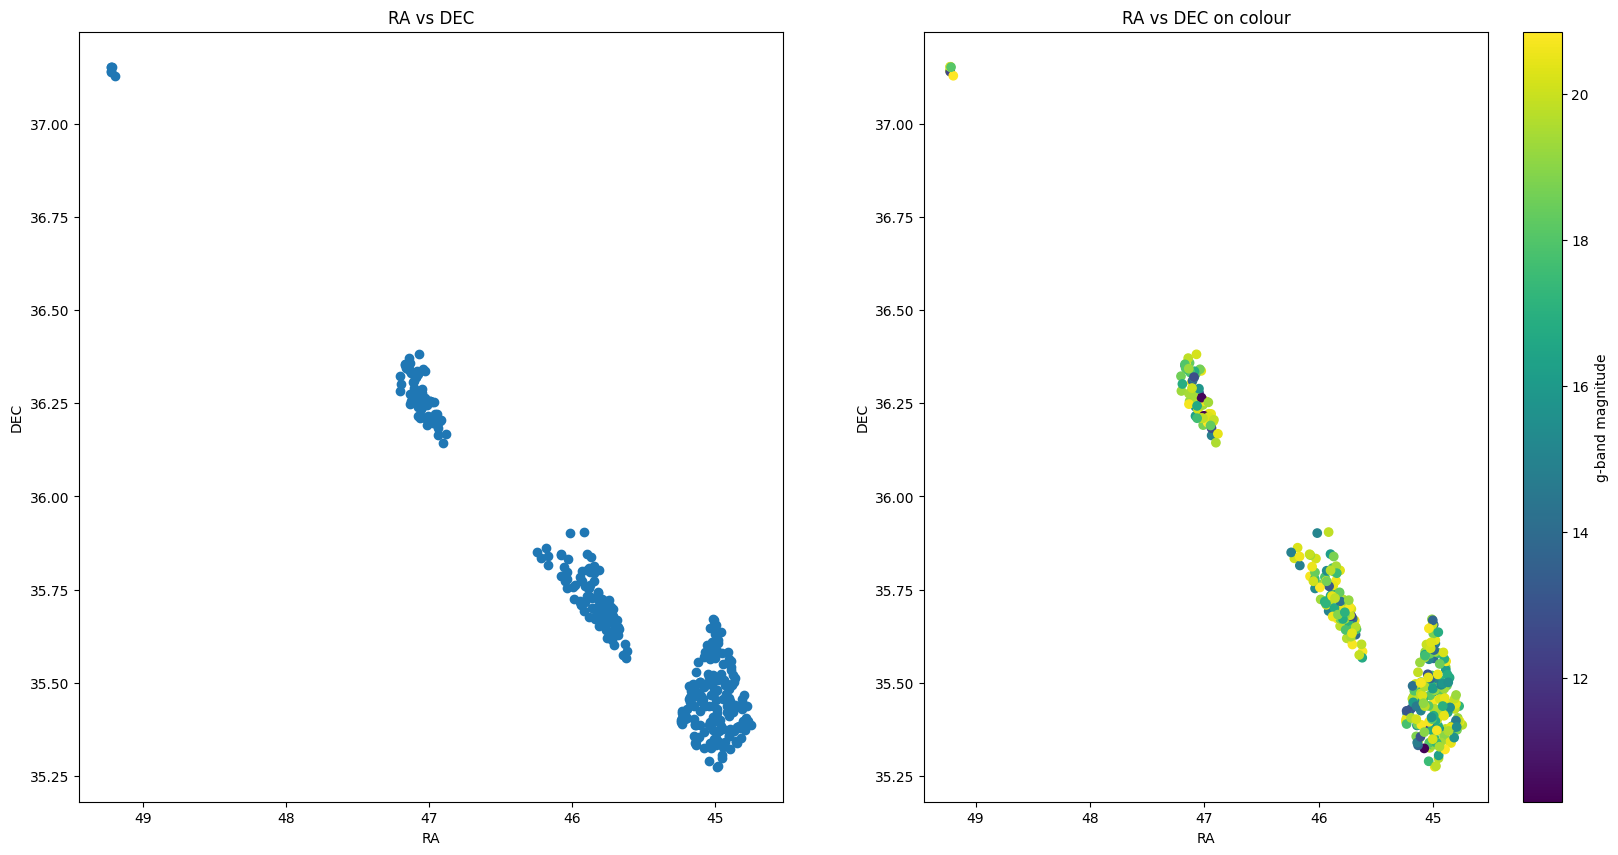

In [ ]:
#plotting distribution of RA and DEC
plt.figure(figsize=(20, 10))
plt.subplot(1,2,1)
plt.scatter(fl_clean['ra'],fl_clean['dec']) #RA and DEC distribution
plt.gca().invert_xaxis()
plt.title('RA vs DEC')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.subplot(1,2,2)
s=plt.scatter(fl_clean['ra'],fl_clean['dec'],c=fl_clean['phot_g_mean_mag'])
plt.gca().invert_xaxis()
plt.colorbar(s).set_label('g-band magnitude') #distribution based on g band magnitude
plt.title('RA vs DEC on colour')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.show()

In [ ]:
#MG​=G+5log10​(ϖ)−10 -> formula for absolute magnitude of G band
fl_clean['mg']=fl_clean['phot_g_mean_mag']+5*np.log10(fl_clean['parallax'])-10
fl_clean.head()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,parallax_over_error,phot_bp_mean_mag,phot_rp_mean_mag,distance_pc,distance_ly,mg
1,137339207152695424,45.030681,35.325036,0.984936,-2.118385,-0.981535,19.782421,1.126236,2.095366,20.274881,19.148645,1015.294444,3311.443746,9.749461
2,137339275872182528,45.016162,35.334053,0.899287,-4.033312,0.064073,18.094265,1.775972,5.683918,18.975348,17.199375,1111.991546,3626.827148,7.863758
7,137340860715191552,45.211665,35.413846,1.750170,-3.385124,-6.507016,15.403451,1.364130,43.176624,16.016058,14.651928,571.372983,1863.567266,6.618852
10,137341852852897664,45.182296,35.456524,1.021926,-0.996170,-3.217922,19.800854,2.187933,2.129362,20.837097,18.649164,978.544576,3191.581847,9.847951
14,137345391907735808,44.970964,35.341406,0.817514,-0.295050,-0.912877,19.892550,1.169691,1.739266,20.458088,19.288397,1223.220478,3989.606983,9.455026


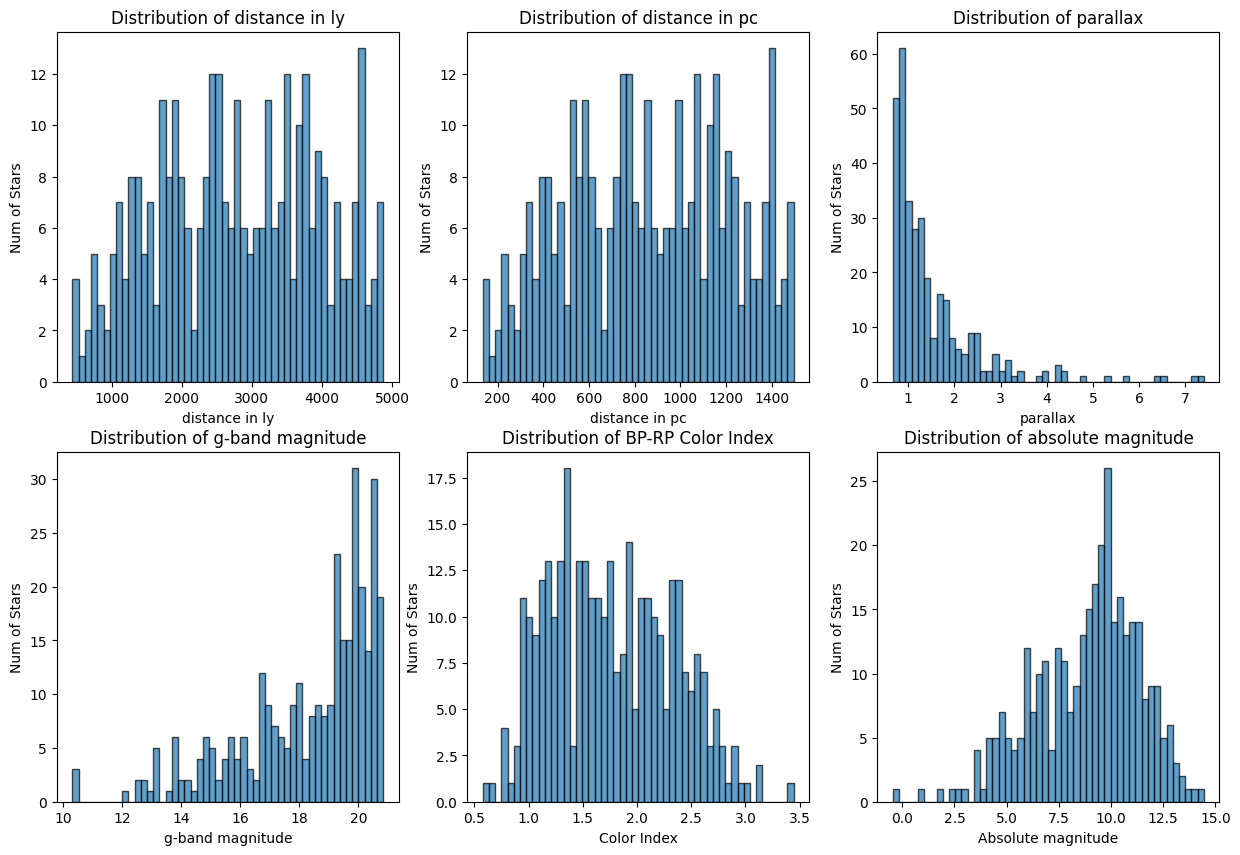

In [ ]:
plt.figure(figsize=(15, 10)) # Create a single figure for all subplots

# Histogram for distance_ly
plt.subplot(2, 3, 1) # First subplot in a 2x3 grid
plt.hist(fl_clean['distance_ly'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of distance in ly')
plt.xlabel('distance in ly')
plt.ylabel('Num of Stars')

# Histogram for distance_pc
plt.subplot(2, 3, 2) # Second subplot
plt.hist(fl_clean['distance_pc'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of distance in pc')
plt.xlabel('distance in pc')
plt.ylabel('Num of Stars')


# Histogram for parallax
plt.subplot(2, 3, 3) # Third subplot
plt.hist(fl_clean['parallax'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of parallax')
plt.xlabel('parallax')
plt.ylabel('Num of Stars')


# Histogram for phot_g_mean_mag
plt.subplot(2, 3, 4) # Fourth subplot
plt.hist(fl_clean['phot_g_mean_mag'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of g-band magnitude')
plt.xlabel('g-band magnitude')
plt.ylabel('Num of Stars')


# Histogram for bp_rp (Color Index)
plt.subplot(2, 3, 5) # Fifth subplot
plt.hist(fl_clean['bp_rp'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of BP-RP Color Index')
plt.xlabel('Color Index')
plt.ylabel('Num of Stars')


# Histogram for mg(absolue magnitude)
plt.subplot(2, 3, 6) # Sixth subplot
plt.hist(fl_clean['mg'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of absolute magnitude')
plt.xlabel('Absolute magnitude')
plt.ylabel('Num of Stars')

plt.show()

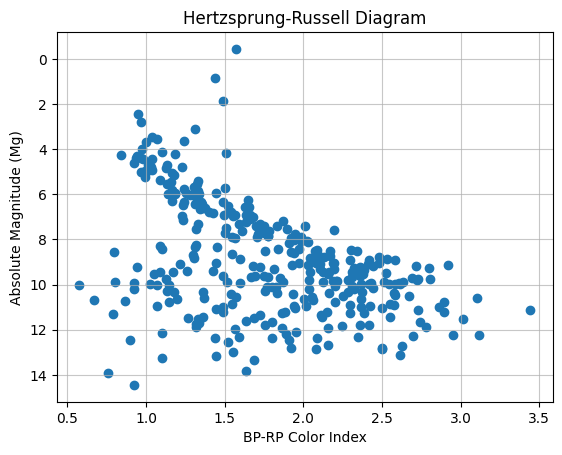

In [ ]:
#HR-Diagram
plt.scatter(fl_clean['bp_rp'],fl_clean['mg'])
plt.gca().invert_yaxis()
plt.xlabel('BP-RP Color Index') # Add x-axis label
plt.ylabel('Absolute Magnitude (Mg)') # Add y-axis label
plt.title('Hertzsprung-Russell Diagram') # Add title
plt.grid(True, alpha=0.7) # Add grid for better readability
plt.show()

**Result and Interpretation:**

*RA vs DEC plots:*

*   The first plot shows the distribution of stars in the celestial coordinates, Right Ascension (RA) and Declination (DEC). It reveals distinct clusters of stars, suggesting that the stars are not uniformly distributed across the sky but rather concentrated in specific regions.
*   The second plot overlays the g-band magnitude onto the RA vs DEC distribution. The color bar indicates that brighter stars (lower magnitude values) tend to be concentrated within these observed clusters. This can provide insights into the stellar populations within these regions, as brighter stars might be closer, more luminous, or part of distinct stellar associations.It mainly conveys info about distribution of luminosity of the stars across the sky.


*Histogram plots:*



*   The first plot shows distribution of distance in light years with respect to the number of stars. It also represents the fact that we chose particularly nearby stars while data cleaning.

*   The second plot shows distribution of distance in parsecs with respect to the number of stars. It also represents the fact that we chose particularly nearby stars while data cleaning.

*   The third plot shows distribution of parallax with respext to stars.Parallax is inversely proportional to distance. This can also tell like previous plots that nearby stars were chosen during data cleaning. This also represents fitering of parallax of positive magnitude.
*   The fourth plot shows distribution of mean magnitude of g-band filter of GAIA spacecraft.


*   The fifth plot shows distribution of color band/luminosity of the stars with respect to their number.


*   The sixth and the last plot shows distribution of absolute magnitude (luminosity) with respect to the number of stars

 Magnitude is a logarithmic scale used to measure brightness. A smaller (or more negative) magnitude indicates a brighter object. Absolute magnitude is a crucial indicator of a star's true power output, independent of its distance.



*HR-Diagram:*  

*   The X axis represents the BP-RP Color Index, which gives information regarding the surface temperature. The left side represents hotter temperature and the right side represents the cooler one.
*   The y axis represents the Absolute Magnite(mg) of the stars, which gives information about it's luminosity.

The diagonal part of the diagram (most crowded) represents the main-sequence phase of star. A star spends most of its life in this phase.

The top right portiondenotes the giants/supergiant phase of the stars.Here, temperature is hotter compared to main sequence stars.

The bottom left portion represents neutron stars( end of star's life).Here, temperature is cooler compared to main sequence stars.

**References:**

The data used is from the DR3 of GAIA mission from European Space Agency(ESA).

*Data Source:* https://gea.esac.esa.int/archive/    (1000 data entries)

I refered to online sources and projects available for the explainations and interpretations I used.

**Conclusion:**

This project involved the analysis of GAIA DR3 stellar data. We performed data cleaning, calculated distances and absolute magnitudes, and visualized various stellar properties, including the Hertzsprung-Russell Diagram. The distributions and variations of stellar parameters were explored with respect to number of stars, providing insights into the characteristics of the observed stars.The project also demonstrates the ability of the Gaia mission in mapping and understanding the galaxy.

**Future Works:**



*   *Kinematic Analysis:* We can do further plots and study with the proper motions(pmra and pmdec) to know more about stellar properties.
*   *Further Data cleaning:* More rigorous data cleaning could be done on parallax,proper motion,parallax_over_error, to study a focussed area of sky and further reduce error.


* *Machine Learning:* Machine Learning can be applied over a wide range of data to know probability about a star's location and predicting other stellar properties.





##Project Part B: Ultraviolet imaging using UIT(Ultra Imaging Telescope) by NASA.

**AIM:** Ultraviolet imaging of celestial objects in a small part of the sky using telescope.Measuring ultraviolet intensity across a small part of sky.

**Data used:** FITS data from UIT telescope during space shuttle mission by NASA.https://fits.gsfc.nasa.gov/samples/UITfuv2582gc.fits

*Metasource:* https://fits.gsfc.nasa.gov/fits_samples.html

In [ ]:
#including required packages
import numpy as np
import matplotlib
from astropy.io import fits
from astropy.stats import sigma_clipped_stats  #to avoid extreme values and maintain a boundary
from astropy.visualization import ImageNormalize,AsinhStretch,ZScaleInterval
from astropy.utils.data import download_file
import matplotlib.pyplot as plt


In [ ]:
#downloading fits file
def download_files():
  fl=download_file("https://fits.gsfc.nasa.gov/samples/UITfuv2582gc.fits",timeout=30,show_progress=True)
  return fl

In [ ]:
#saving image from array data
def save_preview(data:np.ndarray):
  norm=ImageNormalize(data,interval=ZScaleInterval(),stretch=AsinhStretch()) #setting conditiond for better version
  fig = plt.figure()
  plt.imshow(data,norm=norm)
  plt.title("UV Image of Sky")
  plt.xlabel("X PIXEL")
  plt.ylabel("Y PIXEL")
  plt.show()

In [ ]:
def main():
  fl=download_files()
  with fits.open(fl) as hdul:
    hdul.info()
    data=hdul[0].data  #data of file(as array)
    header=hdul[0].header  #headers of file
    print("Headers")
    for card in header.cards:
      print(card)  #printing each headers separately as a list
    print(f"Length of headers: {len(header)}")
    finite_data=data[np.isfinite(data)]
    mean,median,std=sigma_clipped_stats(finite_data)   #parameters from finite part of data
    print(f"Mean: {mean}, Median: {median}, Std: {std}")
    save_preview(data)

Filename: /tmp/astropy-download-5834-bcq2wu1v
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     131   (512, 512)   int16 (rescales to float32)   
Headers
SIMPLE  =                    T  / FLIGHT22 05Apr96 RSH                          
BITPIX  =                  -32 / SIGNED 16-BIT INTEGERS                         
NAXIS   =                    2  / 2-DIMENSIONAL IMAGES                          
NAXIS1  =                  512  / SAMPLES PER LINE                              
NAXIS2  =                  512  / LINES PER IMAGE                               
EXTEND  =                    T  / FILE MAY HAVE EXTENSIONS                      
DATATYPE= 'INTEGER*2'           / SAME INFORMATION AS BITPIX                    
TELESCOP= 'UIT     '            / TELECOPE USED                                 
INSTRUME= 'INTENSIFIED-FILM'    / DETECTOR USED                                 
OBJECT  = 'NGC4151 '            / TARGET NAME                        

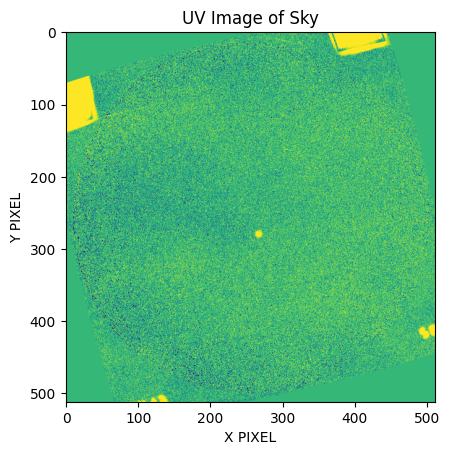

In [ ]:
#call main fn for execution
main()

**Result & Interpretation:**

This program deals with a single 512x512 pixel image with 131 metadata entries. The NAXIS values confirm the presence of 2 dimensional image with 512x512 pixel dimensions.

The telescope used during this mission was Ultra Imaging Telescope(UIT) during NASA's space shuttle mission.

*OBJECT='NGC4151'* denotes that NGC4151 is the celestial object(Seyfert galaxy, an Active Galactic Nuclei), a strong emitter in UV light.

*FILTER = 'B1'* corresponds to the specific B1 bandpass used in spectrum.

*PDSDATIM= '06-JUL-1995 07:20'* referes to the specific date and time when film image was converted to digital data.

The mean,median and std refers to the average UV intensity values , the middle of all the intensity values and the dispersion of UV intensity values around the mean, each of which is either 0(median) or very close to zero(meam,std). This signifies that the background dim light has been removed and background noise has been filtered to obtain a proper data and clean value.

*Image description:* The darker regions show higher UV intensity while the lighter region shows lesser UV intensity. The boxes in the plots are detector artifacts or regions outside field of view of UIT(Ultra Imaging Telescope).The large greenish area having subtle variation in shades of the colour is the main point of view(actual UV emission).

*The bright yellow prominent spot at bottom right could represent a saturated star,left over cosmic ray or another artifact.*

**References:**

I used one of the files from NASA archives of NASA Sample FITS files.

NASA fits files:https://fits.gsfc.nasa.gov/fits_samples.html

UIT Mission observations file:https://fits.gsfc.nasa.gov/samples/UITfuv2582gc.fits

I have refered to online sources and projects available for definitions and explainations I have provided.

**Conclusion:**

This project successfully analyzed UV image data from NASA's Ultra Imaging Telescope (UIT), focusing on the Seyfert galaxy NGC 4151. Key findings included the identification of the target object, the specific filter used, and the date of data digitization. The statistical analysis showed remarkably low mean, median, and standard deviation values, indicating effective background subtraction and noise reduction in the pre-processed data. The visual representation highlighted subtle UV emissions from NGC 4151, along with some detector artifacts. This work provided valuable insights into processing and interpreting astronomical FITS data for UV imaging.

**Future Works:**

*Artifacts Removal:* The artifacts present in this image can be filtered further by cleaning the dataset.

We can obtain images of NGC4151 from other telescopes and compare the results obtain to attain best accuracy.

*Time Series Analysis:* We can obtain change in flux of UV light to detect the variability in UV intensity.This can provide more information on the internal processes of Active Galactic Nulclei.

We can obtain and compare images of other different wavelengths and compare it with UV image. This can give us information about composition of AGN.